In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report


#Librerias para los modelos
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

## Para Red Neuronal
from keras.layers import Input, Dense, Embedding, Flatten, Concatenate
from keras.models import Sequential, Model
from keras.optimizers import Adam
import tensorflow as tf

**Preprocesamiento de los Datos**

Buscamos tener numeros en lugar de texto


In [23]:
#predecir los grd mas repetidos (equilibrar los datos)

# Leer los datos
df = pd.read_csv('../data/dataset_elpino.csv', sep = ';')
df_diagnosticos = pd.read_csv('../data/CIE-10.csv', sep = ',')
df_procedimientos = pd.read_excel('../data/CIE-9.xlsx', converters = {'Código': str})
df_grd = pd.read_csv("../data/Tablas maestras bases GRD.csv")

# Haremos un diccionario para (id diagnostico = numero)
contador = 1 
diccionario = {'-': 0}
diccionario_procedimientos = {'-': 0}
diccionario_grd = {'-': 0}


for a in df_diagnosticos['Código']:
    a = a.strip()
    diccionario[a] = contador
    contador  += 1


'''
Asignar numeros a los DIAGNOSTICOS que tenemos en el dataset en funcion de su id 
     En el dataset, hay que separar el nombre del codigo (diagnosticos)
     Para lograrlo en todas las columnas de diagnosticos
        1. recorremos todas las columnas de diagnosticos
        2. recorremos cada fila de esa columna para dejar registrado los numeros que corresponden a cada codigo
        3. para los valores con (-) los reemplazamos como 0
        3. agregamos la lista al dataset
        4. eliminamos las columnas que ya no nos sirven
'''
contador = 1
for columns in df.iloc[:, 0:35]:
    lista = []
    indice = df.columns.get_loc(columns)
    for a in df[columns]:
        if a == '-':
            lista.append(diccionario[a])
        #####   PREGUNTAR SI ES NORMAL QUE ESTE CODIGO NO ESTE  #####
        elif a.split('-')[0].strip() not in diccionario:
            #print(a.split('-')[0].strip())
            lista.append(0)
        else:    
            codigo = a.split('-')[0].strip()
            lista.append(diccionario[codigo])

    nombre_columna = f'ID_diagnostico {contador}'
    df.insert(indice, nombre_columna, lista)
    df.drop(columns, axis = 1, inplace=True)
    contador += 1

'''
Asignar numeros a los procedimientos segun su ID
    En el dataset, esta formateado de la siguiente forma (codigo - nombre)
    1. Crear un diccionario de los ids de procedimientos
    2. recorremos las columnas de procedimientos
    3. para los valores con (-) los reemplazamos como 0
    4. Agregamos la lista de nuevos ids en el dataset
    5. Eliminamos las columnas que ya no sirven
'''

aux = 1
for codigo in df_procedimientos['Código']:
    codigo = codigo.strip()
    diccionario_procedimientos[codigo] = aux
    aux += 1

contador = 1
for columns in df.iloc[:, 35:65]:
    lista = []
    indice = df.columns.get_loc(columns)
    for a in df[columns]:
        if a == '-':
            lista.append(diccionario_procedimientos[a])
        elif a.split('-')[0].strip() not in diccionario_procedimientos:
            lista.append(0)
        else:
            codigo = a.split('-')[0].strip()
            lista.append(diccionario_procedimientos[codigo])
    nombre_columna = f'ID_procedimiento {contador}'
    df.insert(indice, nombre_columna, lista)
    df.drop(columns, axis = 1, inplace=True)
    contador += 1

'''
Los GRDs los preprocesaremos de la misma forma que hicimos con diagnosticos y procedimientos
    Formato del dataset (Codigo - Nombre)
    1. Crear el diccionario a partir del archivo excel que contiene todos los GRDs
    2. Recorremos la columna de GRD
    3. Se ira llenando una lista con los nuevos valores que tienen los GRDs
    4. Se inserta la lista con los nuevos valores y se elimina la antigua
'''

contador = 1

df_grd.head()
for a in df_grd["IR- GRD"]:
    diccionario_grd[a] = contador
    contador += 1

lista = []
for a in df['GRD']:
    id = int(a.split('-')[0].strip())
    lista.append(diccionario_grd[id])

nombre_columna = 'ID_GRD'
df.insert(68, nombre_columna, lista)
df.drop("GRD", axis = 1, inplace=True)


'''
Para el caso del sexo cambiaremos los valores en 1 si es hombre y 0 si es mujer
'''
sexo = {'Hombre': 1, 'Mujer': 0}
df['Sexo (Desc)'] = df['Sexo (Desc)'].map(sexo)

'''
Imprimimos como quedo la tabla con nuestro preprocesamiento
'''
df.head()



,ID_diagnostico 1,ID_diagnostico 2,ID_diagnostico 3,ID_diagnostico 4,ID_diagnostico 5,ID_diagnostico 6,ID_diagnostico 7,ID_diagnostico 8,ID_diagnostico 9,ID_diagnostico 10,...,ID_procedimiento 24,ID_procedimiento 25,ID_procedimiento 26,ID_procedimiento 27,ID_procedimiento 28,ID_procedimiento 29,ID_procedimiento 30,Edad en años,Sexo (Desc),ID_GRD
0,227,627,3857,10582,895,5295,4984,896,226,4395,...,4633,3895,4030,4038,4108,4104,3751,40,1,913
1,14738,4202,12605,12603,12771,39329,39179,4423,4409,4400,...,4127,4031,4108,4038,4103,4441,4075,53,1,178
2,4739,12787,12786,4380,39158,4207,14749,890,902,622,...,4633,4136,4039,4579,3960,3989,3988,65,1,178
3,4872,4810,10630,1874,2373,2370,4381,10623,4321,12717,...,2334,11,15,4555,4570,4574,4576,61,1,181
4,14587,39106,13299,13385,23644,4425,4207,14749,14738,10712,...,4038,4108,4103,4277,4567,4441,1756,30,1,181


**Analisis Exploratorio de los Datos**

- Analizar los datos
- Cuantas veces aparecen los GRDs
- Cuales son los que mas se repiten


Text(0, 0.5, 'Cantidad de datos')

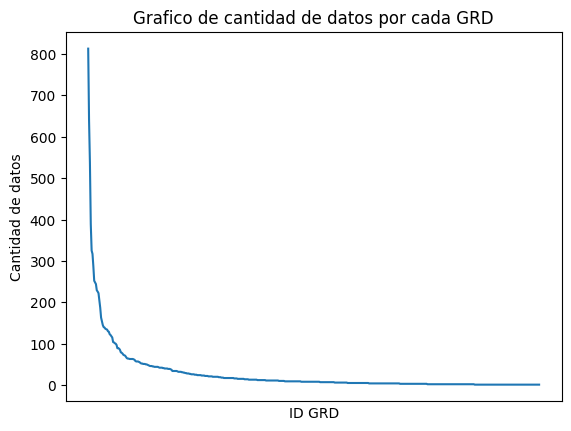

In [19]:
ejey = df['ID_GRD'].value_counts()

ejex = []
for a in df['ID_GRD']:
    if a not in ejex:
        ejex.append(a)
    else:
        pass
ids = ejey.index.tolist()
valores = ejey.values.tolist()

ids_ordenados = [str(id) for id in ids]

plt.plot(ids_ordenados, valores)
plt.title('Grafico de cantidad de datos por cada GRD')
plt.xlabel('ID GRD')
plt.xticks([])
plt.ylabel('Cantidad de datos')

- Mirando el grafico anterior, podemos notar un **claro desbalance** entre los GRDs, mientras que algunos estan por encima de los 100, 200 e incluso 500, hay otros GRDs que no pasan de los 10 datos
- Debido a esa conclusion, si hicieramos un entrenamiento con todo el dataset habran GRDs que no tengan los suficientes datos como para encontrar patrones, por lo tanto, definiremos un umbral para tomar solamente los GRDs que esten por encima de este

Cantidad de GRDs seleccionados:  33


<BarContainer object of 33 artists>

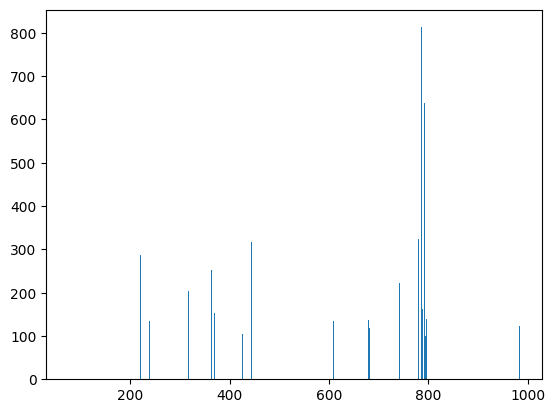

In [27]:
'''
1. Definiremos la frecuencia de cada GRD que aparece en el dataset
2. Definimos un umbral de frecuencia
3. Recopilamos todos los GRDs que superan el umbral
4. Graficamos la frecuencia de cada GRD seleccionado
'''

frecuencia = {}
for id in df['ID_GRD']:
    if id not in frecuencia:
        frecuencia[id] = 1
    else:
        frecuencia[id] += 1

umbral = 100
moda = {}
for i in frecuencia:
    if frecuencia[i] >= umbral:
        moda[i] = frecuencia[i]

ejex = list(moda.keys())
ejey = list(moda.values())    

nuevos_ids = {}
id = 0
for a in ejex:
    nuevos_ids[a] = id
    id += 1

print('Cantidad de GRDs seleccionados: ', len(moda))
plt.bar(ejex, ejey)

In [28]:
'''
A partir de los GRDs seleccionados creamos un nuevo dataset ocupando solamente los datos con los GRDs seleccionados
y tambien le damos un nuevo valor a los GRDs desde el 1 al N
'''

nuevo_dataset = pd.DataFrame()

fila = 0 
for a in df['ID_GRD']:
    if a not in ejex:
        pass
    else:
        fila_copia = df.iloc[fila]
        nuevo_dataset = pd.concat([nuevo_dataset, pd.DataFrame([fila_copia])], ignore_index=True)
    fila += 1

nuevo_dataset['ID_GRD'] = nuevo_dataset['ID_GRD'].replace(nuevos_ids)
nuevo_dataset.head()

,ID_diagnostico 1,ID_diagnostico 2,ID_diagnostico 3,ID_diagnostico 4,ID_diagnostico 5,ID_diagnostico 6,ID_diagnostico 7,ID_diagnostico 8,ID_diagnostico 9,ID_diagnostico 10,...,ID_procedimiento 24,ID_procedimiento 25,ID_procedimiento 26,ID_procedimiento 27,ID_procedimiento 28,ID_procedimiento 29,ID_procedimiento 30,Edad en años,Sexo (Desc),ID_GRD
0,4872,4810,10630,1874,2373,2370,4381,10623,4321,12717,...,2334,11,15,4555,4570,4574,4576,61,1,0
1,14587,39106,13299,13385,23644,4425,4207,14749,14738,10712,...,4038,4108,4103,4277,4567,4441,1756,30,1,0
2,14738,4202,4380,39275,39329,39179,14591,39110,4913,4805,...,4555,4570,4571,4574,4579,4582,4196,37,0,0
3,14738,4202,4423,12771,12632,12603,8186,12615,70,39329,...,4579,4582,4196,4204,4206,4207,4208,59,1,0
4,10620,4881,14738,4425,3913,12785,227,895,39158,14749,...,3828,3865,3751,3859,3786,1756,1764,77,0,0


Text(0, 0.5, 'Cantidad de datos')

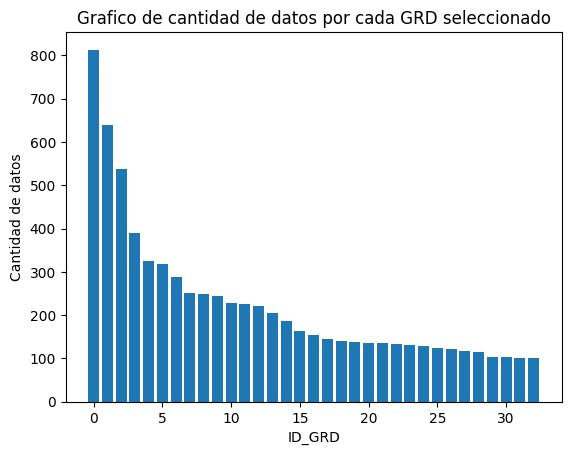

In [29]:
'''
Hacemos un grafico de frecuencia con los GRDs seleccionados
'''

ejey = nuevo_dataset['ID_GRD'].value_counts()
ejex = list(nuevos_ids.values())

plt.bar(ejex, ejey)
plt.title('Grafico de cantidad de datos por cada GRD seleccionado')
plt.xlabel('ID_GRD')
plt.ylabel('Cantidad de datos')

**MODELOS Y ENTRENAMIENTOS**
- Los datos de diagnosticos y procedimientos no representan cantidades ni magnitudes, por lo tanto, debemos ocupar un modelo que ocupe variables categoricas

- Modelos que podemos utilizar 
    - **Decision Tree**
    - **Random Forest**
    - **KNN**

In [30]:
# Separamos los datos en dos: datos de entrenamiento y datos de prueba
lista = []
for a in nuevo_dataset:
    if a != 'ID_GRD':
        lista.append(a)

x = nuevo_dataset[lista]
y = nuevo_dataset['ID_GRD']

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = 42)

######### Random Forest #########
random_forest_model = RandomForestClassifier(n_estimators=100, random_state=42)
random_forest_model.fit(X_train, y_train)

predicciones_random_forest = random_forest_model.predict(X_test)
print('Accuracy Random Forest: ', round(np.mean(predicciones_random_forest == y_test), 2))

######### Decision Tree #########
decision_tree_model = DecisionTreeClassifier(criterion='gini', max_depth=10, random_state=42)
decision_tree_model.fit(X_train, y_train)

predicciones_decision_tree = decision_tree_model.predict(X_test)
print('Accuracy Decision Tree: ', round(np.mean(predicciones_decision_tree == y_test), 2))

Accuracy Random Forest:  0.82
Accuracy Decision Tree:  0.81


In [43]:
print("Accuracy Random Forest:", round(accuracy_score(y_test, predicciones_random_forest), 2))
print("Precision Random Forest:", round(precision_score(y_test, predicciones_random_forest, average='weighted'), 2))
print("Recall Random Forest:", round(recall_score(y_test, predicciones_random_forest, average='weighted'), 2))
print("F1 Score Random Forest:", round(f1_score(y_test, predicciones_random_forest, average='weighted'), 2))

print("\nAccuracy Decision Tree:", round(accuracy_score(y_test, predicciones_decision_tree), 2))
print("Precision Decision Tree:", round(precision_score(y_test, predicciones_decision_tree, average='weighted'), 2))
print("Recall Decision Tree:", round(recall_score(y_test, predicciones_decision_tree, average='weighted'), 2))
print("F1 Score Decision Tree:", round(f1_score(y_test, predicciones_decision_tree, average='weighted'), 2))

Accuracy Random Forest: 0.82
Precision Random Forest: 0.81
Recall Random Forest: 0.82
F1 Score Random Forest: 0.8

Accuracy Decision Tree: 0.81
Precision Decision Tree: 0.8
Recall Decision Tree: 0.81
F1 Score Decision Tree: 0.79


**Matrices de Confusión**
- Teniendo en cuenta que nuestros datos estan desbalanceados los accuracy pueden no ser del todo representativos, por este motivo graficaremos las matrices de confusion de los dos modelos

In [31]:
# Ploteamos matrices de confusion para los dos modelos

'''
A cada matriz de confusion tenemos que agregar la matriz de confusion normalizada, ya que, 
los datos que tenemos en cada clase estan desbalanceados 
'''

def matriz_confusion(reales, predicciones, title):
    matriz = confusion_matrix(reales, predicciones)
    matriz_normalizada = matriz.astype('float') / matriz.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(5, 5))
    plt.imshow(matriz_normalizada, cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicciones')
    plt.ylabel('Real')
    plt.colorbar()
    plt.show()


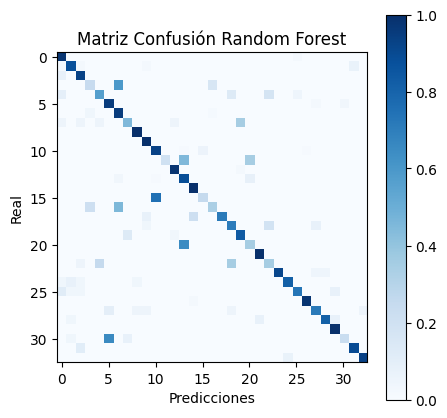

In [ ]:
matriz_confusion(y_test, predicciones_random_forest, 'Matriz Confusión Random Forest')

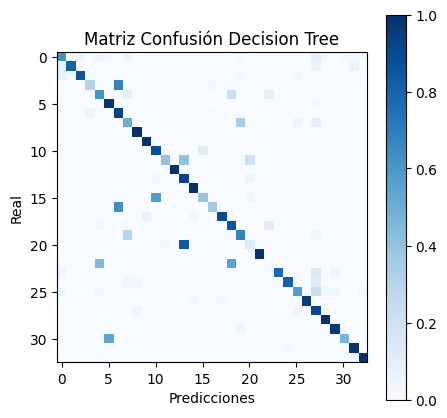

In [32]:
matriz_confusion(y_test, predicciones_decision_tree, 'Matriz Confusión Decision Tree')

**Red Neuronal**
- A partir de los resultados anteriores, intentaremos mejorar el accuracy ocupando **Redes Neuronales**

In [33]:
red_neuronal = Sequential()
red_neuronal.add(Input(shape=(x.shape[1],)))
red_neuronal.add(Dense(128, activation='relu'))
red_neuronal.add(Dense(33, activation='softmax'))
red_neuronal.summary()
optimizer = Adam(learning_rate=1e-3)
red_neuronal.compile(optimizer = optimizer, loss='sparse_categorical_crossentropy', metrics = ['accuracy'])


2025-04-23 20:42:12.928650: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         8,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 33)             │         4,257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,961 (50.63 KB)

 Trainable params: 12,961 (50.63 KB)

 Non-trainable params: 0 (0.00 B)

In [34]:
red_neuronal.fit(X_train, y_train, validation_data=(X_test, y_test), batch_size=64, epochs=32,verbose=1)
predicciones = red_neuronal.predict(X_test)

Epoch 1/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1174 - loss: 5099.7759 - val_accuracy: 0.2254 - val_loss: 1457.7607
Epoch 2/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2339 - loss: 1148.7672 - val_accuracy: 0.2470 - val_loss: 980.2891
Epoch 3/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.3002 - loss: 697.6713 - val_accuracy: 0.2969 - val_loss: 778.3782
Epoch 4/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3309 - loss: 529.6100 - val_accuracy: 0.3279 - val_loss: 669.3438
Epoch 5/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3503 - loss: 490.8721 - val_accuracy: 0.3225 - val_loss: 578.0687
Epoch 6/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3567 - loss: 412.0632 - val_accuracy: 0.3502 - val_loss: 564.9150
Epoch 7/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4020 - loss: 362.4362 - val_accuracy: 0.3212 - val_loss: 543.0948
Epoch 8/32
93/93 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3891 - loss: 334.6048 -

In [35]:
predicciones_red_neuronal = []
for i in range(len(predicciones)):
    index = 0
    for j in predicciones[i]:
        if max(predicciones[i]) == j:
            predicciones_red_neuronal.append(index)
            break
        index += 1

print('Accuracy Red Neuronal: ', round(np.mean(predicciones_red_neuronal == y_test), 2))

Accuracy Red Neuronal:  0.39


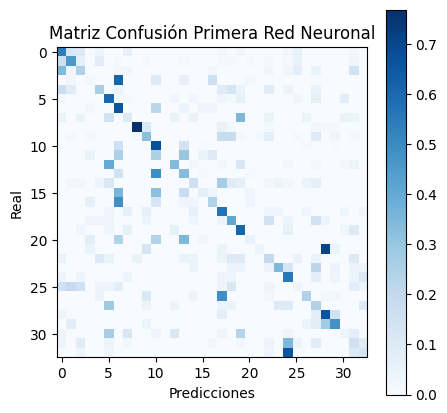

In [36]:
matriz_confusion(y_test, predicciones_red_neuronal, 'Matriz Confusión Primera Red Neuronal')

**NOTA**
- Probablemente la explicacion de que el accuracy de la Red Neuronal sea tan bajo y las predicciones dejen tanto que desear, sea debido a que, el modelo esta intentando encontrar relaciones entre los numeros de los IDs y en nuestro caso esas relaciones no existe, por lo que, ocuparemos embeddings para mejorar el desempeño de nuestra Red Neuronal

**Entrenamiento de Red Neuronal usando Embedding**

In [37]:
n_diagnosticos = len(diccionario)
n_procedimientos = len(diccionario_procedimientos)

inputs_diag = [Input(shape=(1,), name=f'diag_{i}') for i in range(35)]
inputs_proc = [Input(shape=(1,), name=f'proc_{i}') for i in range(30)]

inputs_all = inputs_diag + inputs_proc

input_edad = Input(shape=(1,), name='edad')
input_sexo = Input(shape=(1,), name='sexo')

embedding_diagnosticos = Embedding(input_dim=n_diagnosticos+1, output_dim=128)
embedding_procedimientos = Embedding(input_dim=n_procedimientos+1, output_dim=64)

embedded_diags = [Flatten()(embedding_diagnosticos(inp)) for inp in inputs_diag]
embedded_procs = [Flatten()(embedding_procedimientos(inp)) for inp in inputs_proc]

all_embeddings = Concatenate()(embedded_diags + embedded_procs)
full_input = Concatenate()([all_embeddings, input_edad, input_sexo])

x = Dense(256, activation='relu')(full_input)
x = Dense(128, activation='relu')(x)
output = Dense(33, activation='softmax')(x)

modelo = Model(inputs=inputs_all + [input_edad, input_sexo], outputs=output)
modelo.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

modelo.summary()

2025-04-23 20:42:38.697115: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 20416000 exceeds 10% of free system memory.
2025-04-23 20:42:38.716454: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 20416000 exceeds 10% of free system memory.
2025-04-23 20:42:38.725939: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 20416000 exceeds 10% of free system memory.


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ diag_0 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_1 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_2 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_3 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_4 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_5 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_6 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_7 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_8 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_9 (InputLayer) │ (None, 1)         │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_10             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_11             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_12             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_13             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_14             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_15             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_16             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_17             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_18             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ diag_19             │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                 

 Total params: 7,077,793 (27.00 MB)

 Trainable params: 7,077,793 (27.00 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
columnas_diagnosticos = nuevo_dataset.columns[0:35]
columnas_procedimientos = nuevo_dataset.columns[35:65]

X_train_inputs_diag = [X_train[col_name].values for col_name in columnas_diagnosticos]
X_test_inputs_diag = [X_test[col_name].values for col_name in columnas_diagnosticos]

X_train_inputs_proc = [X_train[col_name].values for col_name in columnas_procedimientos]
X_test_inputs_proc = [X_test[col_name].values for col_name in columnas_procedimientos]

X_train_edad = [X_train['Edad en años'].values]
X_test_edad = [X_test['Edad en años'].values]

X_train_sexo = [X_train['Sexo (Desc)'].values]
X_test_sexo = [X_test['Sexo (Desc)'].values]

X_train_inputs = X_train_inputs_diag + X_train_inputs_proc + [X_train_edad + X_train_sexo]
X_test_inputs = X_test_inputs_diag + X_test_inputs_proc + [X_test_edad + X_test_sexo]


In [49]:
modelo.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = modelo.fit(X_train_inputs, y_train, validation_data=(X_test_inputs, y_test), batch_size=64, epochs=30, verbose=1)

Epoch 1/30


/home/nicoelhulk/Documentos/UNIVERSIDAD/Septimo Semestre/Aprendizaje de Maquina/Proyectos /Proyecto 1/Proyecto1_ML/env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['diag_0', 'diag_1', 'diag_2', 'diag_3', 'diag_4', 'diag_5', 'diag_6', 'diag_7', 'diag_8', 'diag_9', 'diag_10', 'diag_11', 'diag_12', 'diag_13', 'diag_14', 'diag_15', 'diag_16', 'diag_17', 'diag_18', 'diag_19', 'diag_20', 'diag_21', 'diag_22', 'diag_23', 'diag_24', 'diag_25', 'diag_26', 'diag_27', 'diag_28', 'diag_29', 'diag_30', 'diag_31', 'diag_32', 'diag_33', 'diag_34', 'proc_0', 'proc_1', 'proc_2', 'proc_3', 'proc_4', 'proc_5', 'proc_6', 'proc_7', 'proc_8', 'proc_9', 'proc_10', 'proc_11', 'proc_12', 'proc_13', 'proc_14', 'proc_15', 'proc_16', 'proc_17', 'proc_18', 'proc_19', 'proc_20', 'proc_21', 'proc_22', 'proc_23', 'proc_24', 'proc_25', 'proc_26', 'proc_27', 'proc_28', 'proc_29', 'edad', 'sexo']
Received: inputs=

93/93 ━━━━━━━━━━━━━━━━━━━━ 21s 142ms/step - accuracy: 0.9992 - loss: 0.0050 - val_accuracy: 0.9352 - val_loss: 0.4898
Epoch 2/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 113ms/step - accuracy: 0.9985 - loss: 0.0058 - val_accuracy: 0.9345 - val_loss: 0.5073
Epoch 3/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 0.9991 - loss: 0.0047 - val_accuracy: 0.9393 - val_loss: 0.4305
Epoch 4/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 10s 111ms/step - accuracy: 1.0000 - loss: 2.4464e-05 - val_accuracy: 0.9406 - val_loss: 0.4196
Epoch 5/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step - accuracy: 1.0000 - loss: 1.4124e-05 - val_accuracy: 0.9406 - val_loss: 0.4226
Epoch 6/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 132ms/step - accuracy: 1.0000 - loss: 1.2573e-05 - val_accuracy: 0.9426 - val_loss: 0.4234
Epoch 7/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 13s 142ms/step - accuracy: 1.0000 - loss: 1.0171e-05 - val_accuracy: 0.9413 - val_loss: 0.4248
Epoch 8/30
93/93 ━━━━━━━━━━━━━━━━━━━━ 12s 131ms/step - accuracy: 1.0000 - loss: 9.8262e-06 -

In [45]:
predicciones = modelo.predict(X_test_inputs)
predicciones_red_neuronal = []
for i in range(len(predicciones)):
    index = 0
    for j in predicciones[i]:
        if max(predicciones[i]) == j:
            predicciones_red_neuronal.append(index)
            break
        index += 1

print('Accuracy Red Neuronal: ', round(np.mean(predicciones_red_neuronal == y_test), 2))

/home/nicoelhulk/Documentos/UNIVERSIDAD/Septimo Semestre/Aprendizaje de Maquina/Proyectos /Proyecto 1/Proyecto1_ML/env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['diag_0', 'diag_1', 'diag_2', 'diag_3', 'diag_4', 'diag_5', 'diag_6', 'diag_7', 'diag_8', 'diag_9', 'diag_10', 'diag_11', 'diag_12', 'diag_13', 'diag_14', 'diag_15', 'diag_16', 'diag_17', 'diag_18', 'diag_19', 'diag_20', 'diag_21', 'diag_22', 'diag_23', 'diag_24', 'diag_25', 'diag_26', 'diag_27', 'diag_28', 'diag_29', 'diag_30', 'diag_31', 'diag_32', 'diag_33', 'diag_34', 'proc_0', 'proc_1', 'proc_2', 'proc_3', 'proc_4', 'proc_5', 'proc_6', 'proc_7', 'proc_8', 'proc_9', 'proc_10', 'proc_11', 'proc_12', 'proc_13', 'proc_14', 'proc_15', 'proc_16', 'proc_17', 'proc_18', 'proc_19', 'proc_20', 'proc_21', 'proc_22', 'proc_23', 'proc_24', 'proc_25', 'proc_26', 'proc_27', 'proc_28', 'proc_29', 'edad', 'sexo']
Received: inputs=

41/47 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step

/home/nicoelhulk/Documentos/UNIVERSIDAD/Septimo Semestre/Aprendizaje de Maquina/Proyectos /Proyecto 1/Proyecto1_ML/env/lib/python3.12/site-packages/keras/src/models/functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['diag_0', 'diag_1', 'diag_2', 'diag_3', 'diag_4', 'diag_5', 'diag_6', 'diag_7', 'diag_8', 'diag_9', 'diag_10', 'diag_11', 'diag_12', 'diag_13', 'diag_14', 'diag_15', 'diag_16', 'diag_17', 'diag_18', 'diag_19', 'diag_20', 'diag_21', 'diag_22', 'diag_23', 'diag_24', 'diag_25', 'diag_26', 'diag_27', 'diag_28', 'diag_29', 'diag_30', 'diag_31', 'diag_32', 'diag_33', 'diag_34', 'proc_0', 'proc_1', 'proc_2', 'proc_3', 'proc_4', 'proc_5', 'proc_6', 'proc_7', 'proc_8', 'proc_9', 'proc_10', 'proc_11', 'proc_12', 'proc_13', 'proc_14', 'proc_15', 'proc_16', 'proc_17', 'proc_18', 'proc_19', 'proc_20', 'proc_21', 'proc_22', 'proc_23', 'proc_24', 'proc_25', 'proc_26', 'proc_27', 'proc_28', 'proc_29', 'edad', 'sexo']
Received: inputs=

47/47 ━━━━━━━━━━━━━━━━━━━━ 4s 37ms/step
Accuracy Red Neuronal:  0.94


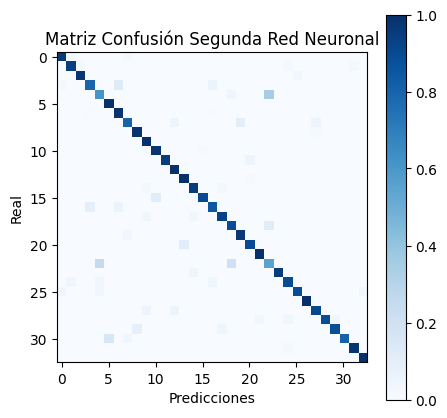

In [46]:
matriz_confusion(y_test, predicciones_red_neuronal, 'Matriz Confusión Segunda Red Neuronal')

In [48]:
print("Accuracy Red Neuronal:", round(accuracy_score(y_test, predicciones_red_neuronal), 2))
print("Precision Red Neuronal:", round(precision_score(y_test, predicciones_red_neuronal, average='weighted'), 2))
print("Recall Red Neuronal:", round(recall_score(y_test, predicciones_red_neuronal, average='weighted'), 2))
print("F1 Score Red Neuronal:", round(f1_score(y_test, predicciones_red_neuronal, average='weighted'), 2))

Accuracy Red Neuronal: 0.94
Precision Red Neuronal: 0.94
Recall Red Neuronal: 0.94
F1 Score Red Neuronal: 0.94


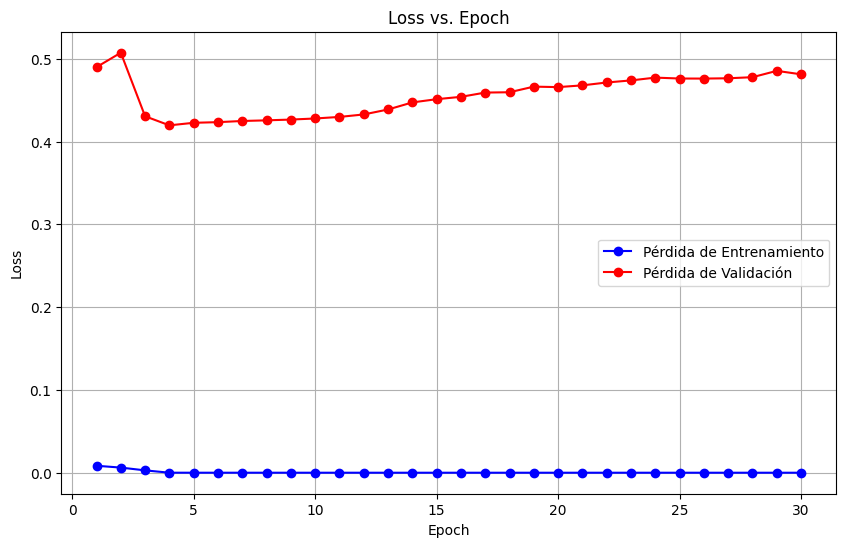

In [51]:
loss = history.history['loss']
val_loss = history.history.get('val_loss')
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo-', label='Pérdida de Entrenamiento')
if val_loss:
    plt.plot(epochs, val_loss, 'ro-', label='Pérdida de Validación')
plt.title('Loss vs. Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()